In [606]:
import ast
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

##### 1. Load the CSV with pandas, drop fully blank rows, and inspect shape, dtypes, and `.info()`.

In [607]:
df = pd.read_csv('E_Mcdonaldsdata.csv')

C:\Users\Shiva Thakur\AppData\Local\Temp\ipykernel_18708\3696745864.py:1: DtypeWarning: Columns (0: table, 1: heading, 2: subheading, 3: 2022, 4: 2021) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('E_Mcdonaldsdata.csv')


In [608]:
df.head()

,table,heading,subheading,2024,2023,2022,2021,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,revenue_breakdown,company_operated,company_operated_us,3197.0,3221.0,"2,836","2,617",NaN,NaN,NaN,NaN,NaN
1,revenue_breakdown,company_operated,company_operated_international_operated_markets,5713.0,5702.0,"5,179","6,456",NaN,NaN,NaN,NaN,NaN
2,revenue_breakdown,company_operated,company_operated_intl_dev_licensed_and_corp,872.0,819.0,733,715,NaN,NaN,NaN,NaN,NaN
3,revenue_breakdown,franchised,franchised_us,7211.0,7163.0,"6,585","6,094",NaN,NaN,NaN,NaN,NaN
4,revenue_breakdown,franchised,franchised_international_operated_markets,6746.0,6549.0,"5,985","5,638",NaN,NaN,NaN,NaN,NaN


In [609]:
print(df.columns.tolist())

['table', 'heading', 'subheading', '2024', '2023', '2022', '2021', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11']


In [610]:
col = ['Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11']
df.drop(columns=col, inplace= True)
print(df.columns.tolist())

['table', 'heading', 'subheading', '2024', '2023', '2022', '2021']


In [611]:
print('Shape of dataset is :', df.shape)
print('Type of dataset in table are :\n',df.dtypes)
df.info()

Shape of dataset is : (1048504, 7)
Type of dataset in table are :
 table             str
heading           str
subheading        str
2024          float64
2023          float64
2022              str
2021              str
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 1048504 entries, 0 to 1048503
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   table       85 non-null     str    
 1   heading     85 non-null     str    
 2   subheading  85 non-null     str    
 3   2024        85 non-null     float64
 4   2023        85 non-null     float64
 5   2022        85 non-null     str    
 6   2021        85 non-null     str    
dtypes: float64(2), str(5)
memory usage: 56.0 MB


In [612]:
df.describe()

,2024,2023
count,85.000000,85.000000
mean,2222.397882,2380.905882
std,13363.431265,12890.163342
min,-77375.000000,-74640.000000
25%,3.000000,12.000000
50%,636.000000,732.000000
75%,2536.000000,2886.000000
max,66834.000000,63480.000000


In [613]:
df.head()

,table,heading,subheading,2024,2023,2022,2021
0,revenue_breakdown,company_operated,company_operated_us,3197.0,3221.0,"2,836","2,617"
1,revenue_breakdown,company_operated,company_operated_international_operated_markets,5713.0,5702.0,"5,179","6,456"
2,revenue_breakdown,company_operated,company_operated_intl_dev_licensed_and_corp,872.0,819.0,733,715
3,revenue_breakdown,franchised,franchised_us,7211.0,7163.0,"6,585","6,094"
4,revenue_breakdown,franchised,franchised_international_operated_markets,6746.0,6549.0,"5,985","5,638"


##### 2. Clean the year columns — strip `$`, `,` and whitespace, then convert to `float`.

In [614]:
def cleanon_ast(val): #Defines a function that will be applied to one cell at a time (one value from your column).
    if pd.isna(val): #Checks if the value is missing (NaN). If it is, just return it as-is — don't try to clean or convert it. 
                     #This prevents an error later, since you can't strip $ and , from something that isn't a real string.
        return val

    clean_data = str(val).replace('$','').replace(',','').strip() 
    #This line does four things in sequence, left to right:
    #str(val) — converts the value to a string (in case it's already a number or some other type).
    #.replace('$', '') — removes every $ character.
    #.replace(',', '') — removes every comma (thousands separator).
    #.strip() — removes leading/trailing whitespace.
    #So " $1,234.50 " becomes "1234.50".
    
    return ast.literal_eval(clean_data) #convert that cleaned string into an actual int/float.

year_cols = ['2021','2022','2023','2024'] #Create a list of the column name you want to clean these should match your DataFrame real column names.

for col in year_cols:#Loop through that list one column name at a time, calling each one col.
    df[col] = df[col].apply(cleanon_ast) #For the current column (col), run clean_with_ast on every cell in that column 
                                         #and overwrite the column with the cleaned results.
                                         #This repeats for each column in year_cols

In [615]:
df.head()

,table,heading,subheading,2024,2023,2022,2021
0,revenue_breakdown,company_operated,company_operated_us,3197.0,3221.0,2836.0,2617.0
1,revenue_breakdown,company_operated,company_operated_international_operated_markets,5713.0,5702.0,5179.0,6456.0
2,revenue_breakdown,company_operated,company_operated_intl_dev_licensed_and_corp,872.0,819.0,733.0,715.0
3,revenue_breakdown,franchised,franchised_us,7211.0,7163.0,6585.0,6094.0
4,revenue_breakdown,franchised,franchised_international_operated_markets,6746.0,6549.0,5985.0,5638.0


##### 3. Pivot the long-format data (`table`, `heading`, `subheading`) into a wide table with one row per `subheading` and one column per year.

In [616]:
df = df.dropna(how='all')  # drop fully-empty rows
print(df.shape)

(85, 7)


In [617]:
wide_df = df.set_index('subheading')[['2021', '2022', '2023', '2024']]
print(wide_df)

                                                   2021    2022    2023  \
subheading                                                                
company_operated_us                              2617.0  2836.0  3221.0   
company_operated_international_operated_markets  6456.0  5179.0  5702.0   
company_operated_intl_dev_licensed_and_corp       715.0   733.0   819.0   
franchised_us                                    6094.0  6585.0  7163.0   
franchised_international_operated_markets        5638.0  5985.0  6549.0   
...                                                 ...     ...     ...   
cash_and_equivalents_increase_(decrease)         1260.0 -2126.0  1996.0   
cash_and_equivalents_at_beginning_of_year        3449.9  4709.0  2584.0   
cash_and_equivalents_at_end_of_year              4709.2  2584.0  4579.0   
interest_paid                                    1197.0  1184.0  1287.0   
income_taxes_paid                                2404.0  3024.0  2993.0   

                        

##### 4. Filter and display only rows where `table == 'revenue_breakdown'`.

In [618]:
df.head()

,table,heading,subheading,2024,2023,2022,2021
0,revenue_breakdown,company_operated,company_operated_us,3197.0,3221.0,2836.0,2617.0
1,revenue_breakdown,company_operated,company_operated_international_operated_markets,5713.0,5702.0,5179.0,6456.0
2,revenue_breakdown,company_operated,company_operated_intl_dev_licensed_and_corp,872.0,819.0,733.0,715.0
3,revenue_breakdown,franchised,franchised_us,7211.0,7163.0,6585.0,6094.0
4,revenue_breakdown,franchised,franchised_international_operated_markets,6746.0,6549.0,5985.0,5638.0


In [619]:
df[df['table'] == 'revenue_breakdown']

,table,heading,subheading,2024,2023,2022,2021
0,revenue_breakdown,company_operated,company_operated_us,3197.0,3221.0,2836.0,2617.0
1,revenue_breakdown,company_operated,company_operated_international_operated_markets,5713.0,5702.0,5179.0,6456.0
2,revenue_breakdown,company_operated,company_operated_intl_dev_licensed_and_corp,872.0,819.0,733.0,715.0
3,revenue_breakdown,franchised,franchised_us,7211.0,7163.0,6585.0,6094.0
4,revenue_breakdown,franchised,franchised_international_operated_markets,6746.0,6549.0,5985.0,5638.0
5,revenue_breakdown,franchised,franchised_intl_dev_licensed_and_corp,1758.0,1724.0,1536.0,1353.0
6,revenue_breakdown,other,other_revenues,423.0,316.0,329.0,351.0


##### 5. Find which `subheading` had the highest value in 2024.

In [620]:
df.head()

,table,heading,subheading,2024,2023,2022,2021
0,revenue_breakdown,company_operated,company_operated_us,3197.0,3221.0,2836.0,2617.0
1,revenue_breakdown,company_operated,company_operated_international_operated_markets,5713.0,5702.0,5179.0,6456.0
2,revenue_breakdown,company_operated,company_operated_intl_dev_licensed_and_corp,872.0,819.0,733.0,715.0
3,revenue_breakdown,franchised,franchised_us,7211.0,7163.0,6585.0,6094.0
4,revenue_breakdown,franchised,franchised_international_operated_markets,6746.0,6549.0,5985.0,5638.0


In [621]:
#clean one-liner showing both the subheading and its value

top_row2024 = df.loc[df['2024'].idxmax()]

#df.loc[..., 'subheading'] uses that index label to look up the subheading value at that row.
#df['2024'].idxmax() finds the index label of the row with the highest value in the 2024 column.

print(top_row2024[['subheading', '2024']])

subheading    retained_earnings
2024                    66834.0
Name: 57, dtype: object


In [622]:
top_row2023 = df.loc[df['2023'].idxmax()]

print(top_row2023[['heading', '2023']])

heading    shareholders
2023            63480.0
Name: 57, dtype: object


##### 6. Group by `heading` and sum values for each year (e.g., total company_operated vs franchised revenue).

In [623]:
df['heading'].value_counts()
#value_counts() just check how many subheadings fall under each heading

heading
current_liabilities                          7
financing_activity                           7
long_term_liabilities                        6
shareholders                                 6
investing_activity                           6
share_data                                   5
charges_and_credit                           5
changes_in_working_capital                   5
operating_costs                              4
current_assets                               4
company_operated                             3
franchised                                   3
operating_costs_company_owned                3
total                                        3
non_operating_cost                           3
other_assets                                 3
lease_and_property                           3
other                                        1
operating_costs_franchise                    1
net_income                                   1
effect_of_exchange_rates                     1
cash_

In [624]:
grouped = df.groupby('heading')[['2021', '2022', '2023', '2024']].sum()

# df.groupby('heading') groups all rows sharing the same heading together.
# [['2021','2022','2023','2024']] selects just the year columns to sum.
# .sum() adds up the values within each group, for each year separately.

print(grouped)

                                              2021      2022     2023  \
heading                                                                 
cash_and_equivalents_at_beginning_of_year   3449.9   4709.00   2584.0   
cash_and_equivalents_at_end_of_year         4709.2   2584.00   4579.0   
cash_and_equivalents_increase_(decrease)    1260.0  -2126.00   1996.0   
changes_in_working_capital                   454.2   -645.00   -108.0   
charges_and_credit                          1142.1   1855.00   1251.0   
company_operated                            9788.0   8748.00   9742.0   
current_assets                              7148.5   5424.20   7986.0   
current_liabilities                         4020.0   3802.10   6859.0   
effect_of_exchange_rates                    -120.1   -254.00    -58.0   
financing_activity                         -5596.5  -6580.00  -4374.0   
franchised                                 13085.0  14106.00  15436.0   
income_taxes_paid                           2404.0 

##### 7. Calculate YoY % growth for each `subheading` between 2021→2022→2023→2024.

In [625]:
years = ['2021', '2022', '2023', '2024']  #Define year list
yoy_df = df[['subheading']].copy() #Creates a fresh table to hold results, starting with just the subheading column.

for i in range(1, len(years)):
    prev_year = years[i-1] #
    curr_year = years[i]
    yoy_df[f'{curr_year}_growth_%'] = (df[curr_year] - df[prev_year]) / df[prev_year] * 100
    #prev_year/curr_year → grabs consecutive year pairs (2021→2022, 2022→2023, 2023→2024).
    #Formula → (new - old) / old * 100 = % growth.

yoy_df = yoy_df.replace([np.inf, -np.inf], np.nan)
print(yoy_df) #Adds a new column to yoy_df for each year pair.

                                         subheading  2022_growth_%  \
0                               company_operated_us       8.368361   
1   company_operated_international_operated_markets     -19.780050   
2       company_operated_intl_dev_licensed_and_corp       2.517483   
3                                     franchised_us       8.057105   
4         franchised_international_operated_markets       6.154665   
..                                              ...            ...   
88         cash_and_equivalents_increase_(decrease)    -268.730159   
89        cash_and_equivalents_at_beginning_of_year      36.496710   
90              cash_and_equivalents_at_end_of_year     -45.128684   
91                                    interest_paid      -1.086048   
92                                income_taxes_paid      25.790349   

    2023_growth_%  2024_growth_%  
0       13.575458      -0.745110  
1       10.098475       0.192915  
2       11.732606       6.471306  
3        8.777525  

##### 8. Identify which line items grew every single year (consistent growth) vs which declined at least once.

In [626]:
growth_cols = ['2022_growth_%', '2023_growth_%', '2024_growth_%']

# Consistent growth = all YoY % values are positive
consistent_growth = yoy_df[(yoy_df[growth_cols] > 0).all(axis=1)]

# Declined at least once = any YoY % value is negative
declined_once = yoy_df[(yoy_df[growth_cols] < 0).any(axis=1)]

print("Grew every year:")
print(consistent_growth[['subheading'] + growth_cols])

print("\nDeclined at least once:")
print(declined_once[['subheading'] + growth_cols])

Grew every year:
                                     subheading  2022_growth_%  2023_growth_%  \
2   company_operated_intl_dev_licensed_and_corp       2.517483      11.732606   
3                                 franchised_us       8.057105       8.777525   
4     franchised_international_operated_markets       6.154665       9.423559   
5         franchised_intl_dev_licensed_and_corp      13.525499      12.239583   
12   franchised_restaurants__occupancy_expenses       0.629550       5.332596   
15                depreciation_and_amortization      12.344556       3.131749   
18                             interest_expense       1.787823      12.758906   
21                   provision_for_income_taxes       4.125861      24.575243   
27                 dividends_declared_per_share       7.809524       6.007067   
34    prepaid_expenses_and_other_current_assets      31.703501      28.601129   
36                                     goodwill       4.237197       4.813129   
37         

##### 9. Compute CAGR (Compound Annual Growth Rate) for revenue and net_income from 2021 to 2024.

In [627]:
# Define the list of revenue segments to sum together into "total revenue"
# (there's no single 'total_revenues' row in this dataset, so we build it manually)
revenue_segments = [
    'company_operated_us',
    'company_operated_international_operated_markets',
    'company_operated_intl_dev_licensed_and_corp',
    'franchised_us',
    'franchised_international_operated_markets',
    'franchised_intl_dev_licensed_and_corp',
    'other_revenues'
]

# Filter df to only the rows whose subheading is in our revenue_segments list,
# then sum their 2021 values to get total revenue for 2021
revenue_2021 = df[df['subheading'].isin(revenue_segments)]['2021'].sum()

# Same as above, but for 2024 — gives total revenue for 2024
revenue_2024 = df[df['subheading'].isin(revenue_segments)]['2024'].sum()

# Filter df to just the single row where subheading == 'net_income'
# (this one already exists as its own line item, so no summing needed)
net_income_row = df[df['subheading'] == 'net_income']

# Calculate CAGR (Compound Annual Growth Rate) for revenue
# using the calc_cagr function defined earlier: (end/start)^(1/periods) - 1
revenue_cagr = calc_cagr(revenue_2021, revenue_2024, 3)

# Calculate CAGR for net_income
# .values[0] pulls the single number out of the filtered row
# (since net_income_row['2021'] is a Series with one value, not a plain number)
net_income_cagr = calc_cagr(net_income_row['2021'].values[0], net_income_row['2024'].values[0], 3)

# Print both results formatted as percentages with 2 decimal places
print(f"Revenue CAGR: {revenue_cagr:.2%}")
print(f"Net Income CAGR: {net_income_cagr:.2%}")

Revenue CAGR: 3.73%
Net Income CAGR: 2.91%


##### 10. Plot a multi-line chart (matplotlib/seaborn) showing revenue, operating_income, and net_income trends over the 4 years.

In [628]:
df.head()

,table,heading,subheading,2024,2023,2022,2021
0,revenue_breakdown,company_operated,company_operated_us,3197.0,3221.0,2836.0,2617.0
1,revenue_breakdown,company_operated,company_operated_international_operated_markets,5713.0,5702.0,5179.0,6456.0
2,revenue_breakdown,company_operated,company_operated_intl_dev_licensed_and_corp,872.0,819.0,733.0,715.0
3,revenue_breakdown,franchised,franchised_us,7211.0,7163.0,6585.0,6094.0
4,revenue_breakdown,franchised,franchised_international_operated_markets,6746.0,6549.0,5985.0,5638.0


In [629]:
labels = ['revenue', 'operating_income', 'net_income']

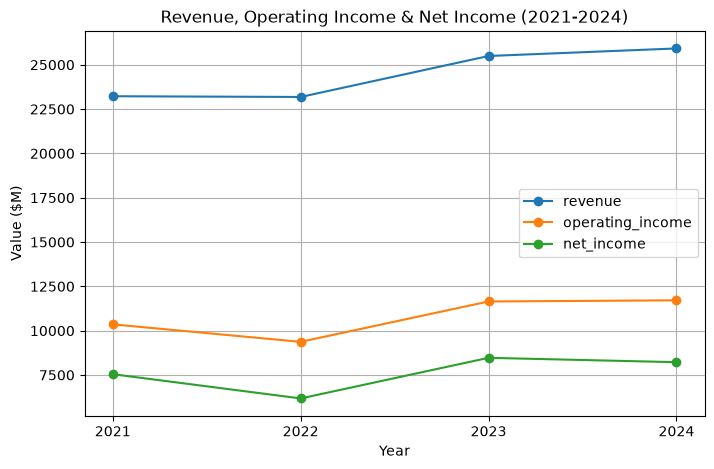

In [630]:
years = ['2021', '2022', '2023', '2024']

revenue_segments = [
    'company_operated_us',
    'company_operated_international_operated_markets',
    'company_operated_intl_dev_licensed_and_corp',
    'franchised_us',
    'franchised_international_operated_markets',
    'franchised_intl_dev_licensed_and_corp',
    'other_revenues'
]

# Sum revenue segments per year to get total revenue
revenue_by_year = df[df['subheading'].isin(revenue_segments)][years].sum()

plt.figure(figsize=(8,5))

# Plot revenue (summed)
plt.plot(years, revenue_by_year.values, marker='o', label='revenue')

# Plot operating_income and net_income (single rows, no summing needed)
for label in ['operating_income', 'net_income']:
    row = df[df['subheading'] == label]
    plt.plot(years, row[years].values.flatten(), marker='o', label=label)

plt.title('Revenue, Operating Income & Net Income (2021-2024)')
plt.xlabel('Year')
plt.ylabel('Value ($M)')
plt.legend()
plt.grid(True)
plt.show()

##### 11. Mean, median, std, variance of YoY growth rates

In [631]:
growth_cols = ['2022_growth_%', '2023_growth_%', '2024_growth_%']

print("Mean:\n", yoy_df[growth_cols].mean())
print("Median:\n", yoy_df[growth_cols].median())
print("Std Dev:\n", yoy_df[growth_cols].std())
print("Variance:\n", yoy_df[growth_cols].var())

Mean:
 2022_growth_%     3.591352
2023_growth_%    12.335067
2024_growth_%    -2.274559
dtype: float64
Median:
 2022_growth_%   -1.354896
2023_growth_%    7.078576
2024_growth_%    1.178866
dtype: float64
Std Dev:
 2022_growth_%    167.353321
2023_growth_%     98.743831
2024_growth_%     64.816079
dtype: float64
Variance:
 2022_growth_%    28007.134002
2023_growth_%     9750.344120
2024_growth_%     4201.124140
dtype: float64


##### 12. Compute the correlation between operating_costs components (e.g., food_and_paper vs payroll_and_employee_benefits) across years.

In [632]:
components = ['food_and_paper', 'payroll_and_employee_benefits']  # match your exact names
comp_df = df[df['subheading'].isin(components)].set_index('subheading')[years].T
print(comp_df.corr())

subheading                     food_and_paper  payroll_and_employee_benefits
subheading                                                                  
food_and_paper                       1.000000                       0.470776
payroll_and_employee_benefits        0.470776                       1.000000


##### 13. Calculate what % of total revenue each segment (company_operated_us, franchised_us, etc.) contributes in 2024, and compare that mix to 2021.

In [633]:
segments = ['company_operated_us', 'franchised_us']  # add all your revenue segments
seg_df = df[df['subheading'].isin(segments)]

total_2024 = seg_df['2024'].sum()
total_2021 = seg_df['2021'].sum()

seg_df = seg_df.copy()
seg_df['pct_2024'] = seg_df['2024'] / total_2024 * 100
seg_df['pct_2021'] = seg_df['2021'] / total_2021 * 100

print(seg_df[['subheading', 'pct_2021', 'pct_2024']])

            subheading   pct_2021   pct_2024
0  company_operated_us  30.042475  30.716756
3        franchised_us  69.957525  69.283244


##### 14. Use `.describe()` to summarize distribution statistics of all 2024 values, and identify outliers using IQR or z-scores.

In [634]:
print(df['2024'].describe())

Q1 = df['2024'].quantile(0.25)
Q3 = df['2024'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['2024'] < lower) | (df['2024'] > upper)]
print(outliers[['subheading', '2024']])

count       85.000000
mean      2222.397882
std      13363.431265
min     -77375.000000
25%          3.000000
50%        636.000000
75%       2536.000000
max      66834.000000
Name: 2024, dtype: float64
                                   subheading     2024
3                               franchised_us   7211.0
4   franchised_international_operated_markets   6746.0
17                           operating_income  11712.0
20                 income_before_income_taxes  10345.0
22                                 net_income   8223.0
38               lease_right_of_use_asset_net  13339.0
39             property_and_equipment_at_cost  44177.0
40  accumulated_depreciation_and_amortization -18882.0
48                             long_term_debt  38424.0
49                  long_term_lease_liability  12888.0
56                 additional_paid_in_capital   9281.0
57                          retained_earnings  66834.0
59                    treasury_stock_at_cost_ -77375.0
60                         

##### 15. Build a simple linear regression (using `numpy.polyfit` or `sklearn`) to project 2025 revenue based on the 2021–2024 trend.

In [635]:
revenue_segments = [
    'company_operated_us',
    'company_operated_international_operated_markets',
    'company_operated_intl_dev_licensed_and_corp',
    'franchised_us',
    'franchised_international_operated_markets',
    'franchised_intl_dev_licensed_and_corp',
    'other_revenues'
]

x = np.array([2021, 2022, 2023, 2024])
y = df[df['subheading'].isin(revenue_segments)][years].sum().values

slope, intercept = np.polyfit(x, y, 1)
revenue_2025 = slope * 2025 + intercept

print(f"Projected 2025 Revenue: {revenue_2025:.2f}")

Projected 2025 Revenue: 27055.00


##### 16. Probability 2025 net_income growth exceeds target (normal distribution)

In [636]:
from scipy.stats import norm

net_income_growth = yoy_df[yoy_df['subheading'] == 'net_income'][growth_cols].values.flatten()

mean_growth = np.mean(net_income_growth)
std_growth = np.std(net_income_growth)
target = 5  # target % growth

prob_exceed = 1 - norm.cdf(target, loc=mean_growth, scale=std_growth)
print(f"Probability 2025 net_income growth exceeds {target}%: {prob_exceed:.2%}")

Probability 2025 net_income growth exceeds 5%: 50.61%


##### 17. Run a Monte Carlo simulation (1,000+ trials) using the historical mean/std of revenue growth to simulate a range of possible 2025 revenue outcomes, then plot the distribution.

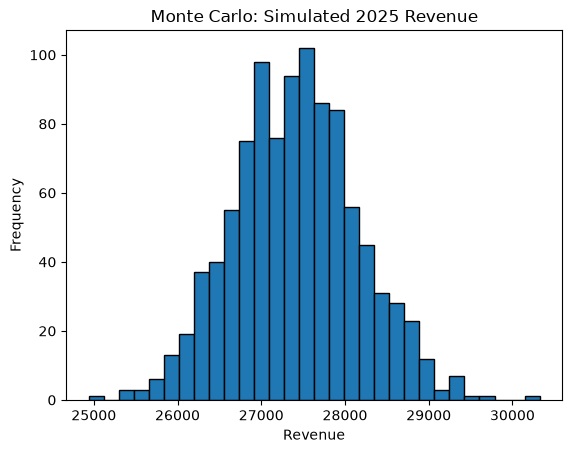

Mean simulated 2025 revenue: 27414.60


In [637]:
revenue_segments = [
    'company_operated_us',
    'company_operated_international_operated_markets',
    'company_operated_intl_dev_licensed_and_corp',
    'franchised_us',
    'franchised_international_operated_markets',
    'franchised_intl_dev_licensed_and_corp',
    'other_revenues'
]

# Sum revenue growth % across all segments, per year, then average across segments to get overall revenue growth
revenue_growth = yoy_df[yoy_df['subheading'].isin(revenue_segments)][growth_cols].mean().values

mean_g, std_g = np.mean(revenue_growth), np.std(revenue_growth)

revenue_2024 = df[df['subheading'].isin(revenue_segments)]['2024'].sum()

np.random.seed(42)
simulated_growth = np.random.normal(mean_g, std_g, 1000)
simulated_2025 = revenue_2024 * (1 + simulated_growth / 100)

plt.hist(simulated_2025, bins=30, edgecolor='black')
plt.title('Monte Carlo: Simulated 2025 Revenue')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.show()

print(f"Mean simulated 2025 revenue: {simulated_2025.mean():.2f}")

##### 18. Calculate the probability that operating expenses grow faster than revenue in a given year, based on historical frequency across the dataset's line items.


In [638]:
opex_items = ['food_and_paper', 'payroll_and_employee_benefits']  # your opex line items

revenue_segments = [
    'company_operated_us',
    'company_operated_international_operated_markets',
    'company_operated_intl_dev_licensed_and_corp',
    'franchised_us',
    'franchised_international_operated_markets',
    'franchised_intl_dev_licensed_and_corp',
    'other_revenues'
]

# Build total revenue by year, then compute its YoY growth (as before)
revenue_by_year = df[df['subheading'].isin(revenue_segments)][years].sum()

revenue_growth_by_year = {
    '2022_growth_%': (revenue_by_year['2022'] - revenue_by_year['2021']) / revenue_by_year['2021'] * 100,
    '2023_growth_%': (revenue_by_year['2023'] - revenue_by_year['2022']) / revenue_by_year['2022'] * 100,
    '2024_growth_%': (revenue_by_year['2024'] - revenue_by_year['2023']) / revenue_by_year['2023'] * 100,
}

opex_growth = yoy_df[yoy_df['subheading'].isin(opex_items)][growth_cols]

faster_count = 0
total_count = 0
for col in growth_cols:
    rev_g = revenue_growth_by_year[col]  # look up revenue growth for this year directly
    for val in opex_growth[col].dropna():
        total_count += 1
        if val > rev_g:
            faster_count += 1

prob = faster_count / total_count
print(f"Probability opex grows faster than revenue: {prob:.2%}")

Probability opex grows faster than revenue: 50.00%


##### 19. Use bootstrapping (resampling with replacement) on the YoY growth rates to estimate a confidence interval for expected 2025 growth.

In [639]:
all_growth = yoy_df[growth_cols].values.flatten()
all_growth = all_growth[~np.isnan(all_growth)]  # drop NaNs

np.random.seed(42)
boot_means = [np.mean(np.random.choice(all_growth, size=len(all_growth), replace=True)) for _ in range(1000)]

ci_lower = np.percentile(boot_means, 2.5)
ci_upper = np.percentile(boot_means, 97.5)

print(f"95% CI for expected growth: [{ci_lower:.2f}%, {ci_upper:.2f}%]")

95% CI for expected growth: [-9.89%, 19.57%]


##### 20. Compare two "what-if" scenarios (optimistic vs conservative growth assumptions) and calculate the probability-weighted expected net_income for 2025.

In [640]:
net_income_2024 = df[df['subheading'] == 'net_income']['2024'].values[0]

optimistic_growth = 0.08   # 8%
conservative_growth = 0.02 # 2%
prob_optimistic = 0.4      # 40% chance
prob_conservative = 0.6    # 60% chance

optimistic_2025 = net_income_2024 * (1 + optimistic_growth)
conservative_2025 = net_income_2024 * (1 + conservative_growth)

expected_net_income = (prob_optimistic * optimistic_2025) + (prob_conservative * conservative_2025)

print(f"Expected 2025 net_income: {expected_net_income:.2f}")

Expected 2025 net_income: 8584.81
